**Ders: K-Means Kümeleme Analizi Uygulaması**
Giriş: K-Means Nedir?

K-Means, verileri birbirine olan benzerliklerine (uzaklıklarına) göre k adet kümeye ayıran bir denetimsiz öğrenme algoritmasıdır. Temel amacı, küme içi hata kareler toplamını (SSD/SSE) minimize etmektir.

**1. Aşama: Ortamın Hazırlanması ve Kütüphaneler**

İlk olarak, veri işleme, görselleştirme ve makine öğrenmesi için gerekli kütüphaneleri çalışma ortamımıza dahil ediyoruz. yellowbrick kütüphanesi, model performansını görselleştirmek için kritik öneme sahiptir

In [ ]:
# Gerekli görselleştirme kütüphanesinin kurulumu
!pip install yellowbrick -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from yellowbrick.cluster import KElbowVisualizer
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.decomposition import PCA

**2. Aşama: Veri Setinin Okunması ve İncelenmesi**

Analizimizde 1973 yılına ait ABD eyaletlerinin suç istatistiklerini içeren USArrests.csv dosyasını kullanıyoruz.

In [ ]:
try:
    # Eyalet isimlerini index yaparak veriyi oku
    df = pd.read_csv("USArrests.csv", index_col=0)
    print("Veri seti başarıyla yüklendi!")
    display(df.head())
except FileNotFoundError:
    print("Hata: 'USArrests.csv' dosyası bulunamadı.")

Veri seti başarıyla yüklendi!


,Murder,Assault,UrbanPop,Rape
State,,,,
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


In [ ]:
df.isnull().sum()

,0
Murder,0
Assault,0
UrbanPop,0
Rape,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50 entries, Alabama to Wyoming
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Murder    50 non-null     float64
 1   Assault   50 non-null     int64  
 2   UrbanPop  50 non-null     int64  
 3   Rape      50 non-null     float64
dtypes: float64(2), int64(2)
memory usage: 2.0+ KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Murder,50.0,7.788,4.355510,0.8,4.075,7.25,11.250,17.4
Assault,50.0,170.760,83.337661,45.0,109.000,159.00,249.000,337.0
UrbanPop,50.0,65.540,14.474763,32.0,54.500,66.00,77.750,91.0
Rape,50.0,21.232,9.366385,7.3,15.075,20.10,26.175,46.0


**3. Aşama: Veri Ön İşleme (Standardizasyon)**

K-Means uzaklık temelli bir algoritma olduğu için, farklı ölçeklerdeki değişkenler (örneğin: Saldırı sayıları yüzlerdeyken, Cinayet oranlarının onlarda olması) sonucu bozabilir. Bu nedenle verileri standart bir aralığa (örneğin 0-1) çekiyoruz.

In [ ]:
# Verileri 0 ile 1 arasına ölçeklendiriyoruz
sc = MinMaxScaler(feature_range=(0, 1))
df_scaled = sc.fit_transform(df)

**4. Aşama: Optimum Küme Sayısının Belirlenmesi**

"En iyi kaç kümeye ayırmalıyız?" sorusuna Dirsek (Elbow) Yöntemi ile yanıt arıyoruz

**Denetimsiz Öğrenme:** K-Means Algoritmasında Optimum Küme Sayısının Belirlenmesi K-Means algoritması ile gerçekleştirilen kümeleme analizlerinde, algoritmanın en temel parametresi olan küme sayısı (k), varsayılan olarak (örneğin Scikit-learn kütüphanesinde) 8 olarak belirlenmiştir. Ancak bu parametre, verinin doğasına ve çalışmanın amacına göre optimize edilmesi gereken bir "hiperparametre"dir. Optimum küme sayısını belirlemek için kullanılan en yaygın yaklaşımlar ve dikkate alınması gereken hususlar aşağıda akademik bir çerçevede özetlenmiştir.

Hata Kareler Toplamı (SSE / SSD) ve Dirsek Yöntemi
Kümeleme performansını ölçmek için kullanılan temel metrik, her gözlem biriminin atandığı küme merkezine olan uzaklıklarının kareler toplamıdır. Bu değer literatürde SSE (Sum of Squared Errors), SSR (Sum of Squared Residuals) veya SSD (Sum of Squared Distances) olarak adlandırılır.

Matematiksel olarak, küme sayısı arttıkça her bir gözlemin bir merkeze daha yakın olması beklenir; dolayısıyla küme sayısı gözlem sayısına yaklaştıkça hata sıfıra doğru meyil eder. Ancak aşırı kümeleme (over-clustering), verinin anlamlı bir şekilde gruplanmasını engeller. Dirsek (Elbow) Yöntemi, bu hata düşüş hızının keskin bir şekilde azaldığı "kırılma" noktasını referans alarak optimum küme sayısını önerir.

İstatistiksel Referans ve Otomatik Belirleme
Manuel döngülerle hesaplanan SSD değerlerinin yorumlanması bazen sübjektif olabilir. Bu noktada Yellowbrick kütüphanesinin sunduğu KElbowVisualizer gibi fonksiyonlar, Distortion Score (Bozulma Skoru) ve hesaplama süresini (Fit Time) analiz ederek matematiksel olarak en belirgin dirsek noktasını otomatik olarak tespit eder. Örneğin, USArrests veri seti özelinde bu değerin 4 veya 5 olarak belirlenmesi, istatistiksel bir referans sinyali oluşturur.

İş Bilgisi (Domain Knowledge) ve Algoritmanın Sınırları
Denetimsiz öğrenme süreçlerinde algoritmanın sunduğu matematiksel çıktılar, analizin nihai sonucu değil, yalnızca birer "karar destek sinyali" olarak kabul edilmelidir. Gerçek dünya senaryolarında şu iki unsur kritik öneme sahiptir:

Operasyonel Verimlilik: Stratejik veya lojistik nedenlerle (örneğin kargo dağıtım ağları veya müşteri ziyaret planları), algoritmanın matematiksel olarak önerdiği gruplandırmalar coğrafi veya ticari gerçeklerle örtüşmeyebilir. Birbirine yakın olan fakat farklı kümelerde çıkan birimlerin manuel olarak birleştirilmesi gerekebilir.

İnsan Dokunuşu ve Sezgisellik: Analist, algoritmanın önerdiği küme sayısını kendi tecrübesi ve iş bilgisiyle harmanlamalıdır. Örneğin, İstanbul gibi tek başına devasa bir büyüklüğe sahip bir birimin, algoritma aksini söylese dahi ayrı bir segment olarak değerlendirilmesi "iş bilgisi" (domain knowledge) gereğidir.

Sonuç

Kümeleme analizi, saf bir matematiksel optimizasyon süreci değildir. En iyi sonuç; algoritmanın sağladığı istatistiksel referansların (SSD, Elbow Point), analistin alan tecrübesi ve operasyonel kısıtları ile sentezlenmesi sonucunda elde edilir. Dolayısıyla analist, süreci yalnızca algoritmaya bırakmamalı, verinin içindeki anlamlı yapıları ortaya çıkarırken kendi dokunuşlarını ve stratejik bakış açısını sürece dahil etmelidir.

**A. Manuel İnceleme (SSD Değerleri)**

Küme sayısı arttıkça toplam hata azalır. Hata düşüş hızının keskin bir şekilde azaldığı "kırılma" noktası ideal küme sayısını verir

Kodun İşlevi:

ssd.append(kmeans.inertia_): Her bir küme sayısı için hesaplanan "Hata Kareler Toplamı"nı (SSE) listeye ekler.

plt.plot(K, ssd, "bx-"): x ekseninde küme sayısını (K), y ekseninde ise hatayı (ssd) gösteren mavi renkli, işaretçili bir çizgi grafik oluşturur.

Dirsek Noktası: Grafik çizildiğinde, hatanın keskin bir düşüşten sonra yataylaşmaya başladığı o kırılma noktası size ideal küme sayısını verir.



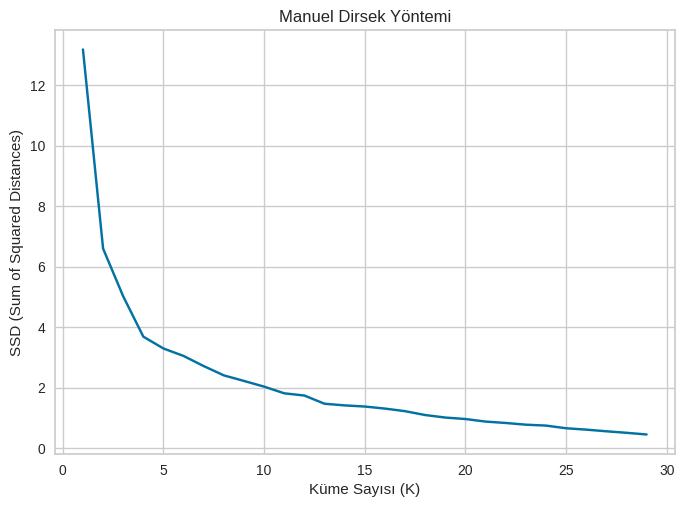

In [ ]:
ssd = []
K = range(1, 30)
for k in K:
    kmeans_model = KMeans(n_clusters=k, random_state=17).fit(df_scaled)
    ssd.append(kmeans_model.inertia_)

plt.plot(K, ssd, "bx-")
plt.xlabel("Küme Sayısı (K)")
plt.ylabel("SSD (Sum of Squared Distances)")
plt.title("Manuel Dirsek Yöntemi")
plt.show()

**B. Yellowbrick ile Otomatik Karar**

KElbowVisualizer fonksiyonu, matematiksel olarak en belirgin dirsek noktasını otomatik tespit eder.

Kodun İşlevi:

KElbowVisualizer(kmeans, k=(2, 20)): 2 ile 20 arasındaki tüm k değerlerini otomatik olarak test eden görselleştiriciyi tanımlar.

elbow.fit(df): Modeli verileriniz üzerinde eğitir ve her bir k için skorları hesaplar.

elbow.show(): Dirsek noktasını (elbow point) işaretleyen profesyonel istatistiksel grafiği ekrana basar.

elbow.elbow_value_: Grafikteki kırılma noktasına göre matematiksel olarak belirlenmiş olan ideal küme sayısını size verir.

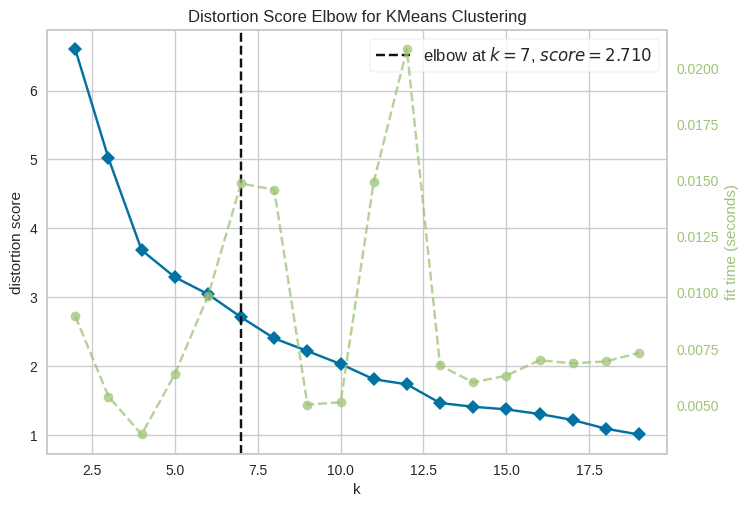

Önerilen Optimum Küme Sayısı: 7


In [ ]:
kmeans = KMeans(random_state=17)
elbow = KElbowVisualizer(kmeans, k=(2, 20))
elbow.fit(df_scaled)
elbow.show()

print(f"Önerilen Optimum Küme Sayısı: {elbow.elbow_value_}")

**5. Aşama: Final Modelin Kurulması ve Değerlendirme**

Algoritmanın önerdiği k değeri ile nihai modeli kuruyor ve eyaletleri kümelerine atıyoruz

In [ ]:
# Optimum k değeri ile modeli eğit
optimum_k = elbow.elbow_value_
final_model = KMeans(n_clusters=optimum_k, random_state=17).fit(df_scaled)

# Küme etiketlerini (0, 1, 2...) orijinal veriye 1'den başlayarak ekle
df["Cluster"] = final_model.labels_ + 1

# Sonuçları incele
print("\nKümelerine Ayrılmış Eyalet Listesi (İlk 10):")
print(df.sort_values(by="Cluster").head(10))


Kümelerine Ayrılmış Eyalet Listesi (İlk 10):
               Murder  Assault  UrbanPop  Rape  Cluster
State                                                  
Iowa              2.2       56        57  11.3        1
Idaho             2.6      120        54  14.2        1
Minnesota         2.7       72        66  14.9        1
Maine             2.1       83        51   7.8        1
New Hampshire     2.1       57        56   9.5        1
Vermont           2.2       48        32  11.2        1
West Virginia     5.7       81        39   9.3        1
North Dakota      0.8       45        44   7.3        1
South Dakota      3.8       86        45  12.8        1
Wisconsin         2.6       53        66  10.8        1


**Sonuç: İş Bilgisi ve Karar Verme**

Kümeleme analizi sadece bir matematiksel optimizasyon değildir. Algoritmanın önerisi bir "karar destek sinyali"dir; nihai küme sayısı belirlenirken iş bilgisi (operasyonel verimlilik, coğrafi kısıtlar) mutlaka sürece dahil edilmelidir

**6. Aşama: Nihai Modelin Kurulması ve Veri Entegrasyonu**

Optimum küme sayısını (örneğin k=5) belirledikten sonra, tüm veri setini bu parametre ile yeniden eğitiyoruz. Algoritmanın ürettiği küme etiketlerini (labels), analizin başında okuduğumuz orijinal veri setine bir değişken olarak ekliyoruz. Böylece her bir gözlem biriminin (eyaletin) hangi segmentte yer aldığını somutlaştırıyoruz.

In [ ]:
# 1. Optimum k değeri ile final modelin kurulması
# Yellowbrick'ten gelen elbow_value_ kullanılarak model fit edilir.
final_kmeans = KMeans(n_clusters=elbow.elbow_value_, random_state=17).fit(df_scaled)

# 2. Küme etiketlerinin orijinal DataFrame'e aktarılması
# İndis uyumu için etiketler 'Cluster' sütunu olarak eklenir.
df["Cluster"] = final_kmeans.labels_

# 3. Kullanıcı dostu isimlendirme (1'den başlatma)
df["Cluster"] = df["Cluster"] + 1

# Sonuçların ilk gözlemi
display(df.head())

,Murder,Assault,UrbanPop,Rape,Cluster
State,,,,,
Alabama,13.2,236,58,21.2,5
Alaska,10.0,263,48,44.5,2
Arizona,8.1,294,80,31.0,2
Arkansas,8.8,190,50,19.5,4
California,9.0,276,91,40.6,2


**7. Aşama: Küme Tanımlama ve Betimsel İstatistikler**

Kümeleme işlemi tamamlandığında, sadece hangi birimin nerede olduğunu bilmek yeterli değildir; her bir kümenin hangi karakteristik özelliklere sahip olduğunun analiz edilmesi gerekir. groupby metodu kullanılarak her kümenin değişken bazındaki ortalamaları ve gözlem sayıları incelenir.

In [ ]:
# Kümelerin istatistiksel özetinin çıkarılması
# Her küme için gözlem sayısı (count) ve değişken ortalamaları (mean) hesaplanır.
cluster_summary = df.groupby("Cluster").agg(["count", "mean"])
display(cluster_summary)

Murder            Assault             UrbanPop             Rape  \
         count       mean   count        mean    count       mean count   
Cluster                                                                   
1           10   2.680000      10   70.100000       10  51.000000    10   
2           12  10.966667      12  264.000000       12  76.500000    12   
3           11   6.363636      11  143.909091       11  68.454545    11   
4            4   7.825000       4  142.250000        4  53.750000     4   
5            4  14.800000       4  221.000000        4  60.750000     4   
6            3  14.500000       3  291.666667        3  45.666667     3   
7            6   4.500000       6  126.333333        6  83.500000     6   

                    
              mean  
Cluster             
1        10.910000  
2        33.608333  
3        21.090909  
4        16.950000  
5        24.025000  
6        18.566667  
7        16.266667

**Akademik Yorum ve İş Bilgisi Entegrasyonu:**
Analiz sonucunda, örneğin iki farklı kümenin cinayet oranları birbirine çok yakın çıkabilir (10 ve 14 gibi). Bu noktada analist, sadece matematiksel uzaklıklara değil, değişkenlerin çalışmadaki önemine (örneğin cinayet oranının kritik bir faktör olması) odaklanarak kümeleri manuel olarak birleştirmeyi veya ayırmayı tercih edebilir. Unutulmamalıdır ki; denetimsiz öğrenme modelleri birer "karar verici" değil, analiste yol gösteren sinyal üreticilerdir.

**8. Aşama: Sonuçların Dışa Aktarılması (Raporlama)**

Elde edilen segmentasyon sonuçları, iş paydaşlarına veya diğer birimlere sunulmak üzere standart dosya formatlarına dönüştürülmelidir.

In [ ]:
# Sonuçların CSV formatında kaydedilmesi
df.to_csv("USArrests_Clustered.csv")
print("Segmentasyon sonuçları 'USArrests_Clustered.csv' olarak kaydedildi.")

Segmentasyon sonuçları 'USArrests_Clustered.csv' olarak kaydedildi.


**Özet: Analistin Rolü**

K-Means süreci, verinin ölçeklendirilmesinden (scaling) başlayıp, matematiksel referansların (elbow point) yorumlanması ve en nihayetinde iş bilgisi (domain knowledge) ile harmanlanmasıyla tamamlanır. Sosyal medya verilerinden suç istatistiklerine kadar her senaryoda asıl katma değer, algoritmanın gruplandırdığı birimleri analistin kendi tecrübesiyle anlamlandırması ve stratejik bir aksiyon planına dönüştürmesidir.